In [1]:
import numpy as np
import pandas as pd

# ----------------------------
# 1) CONFIG
# ----------------------------
RNG_SEED = 42
np.random.seed(RNG_SEED)

WEEKS = 52
DAYS_PER_WEEK = 7

# Greater Manchester boroughs (synthetic "whole of Manchester" coverage)
AREAS = [
    "Manchester", "Salford", "Trafford", "Stockport", "Tameside",
    "Rochdale", "Oldham", "Bury", "Bolton", "Wigan"
]

# Two businesses with different "menus" (product mix) and strategies
BUSINESSES = [
    {
        "business_id": "A",
        "name": "Northern Pages (Indie Bookshop)",
        # Slightly higher prices, more collectors, better upsell on hardback/specials
        "price_multiplier": 1.05,
        "fixed_weekly_cost": 3200,      # rent/staff/utilities allocation per week
        "variable_cost_ratio": 0.58,    # cost of goods ratio (COGS) per revenue
        "membership_uptake": 0.10,      # portion of customers buying membership/club
        "membership_price": 12.0,       # per transaction (simplified)
        "menu_mix": {
            "Paperback": 0.42,
            "Hardback": 0.25,
            "Box Set": 0.10,
            "Audiobook Card": 0.08,
            "Ebook Code": 0.07,
            "Collector/Signed": 0.08
        }
    },
    {
        "business_id": "B",
        "name": "MCR Book Hub (Big Retail Chain)",
        # Slightly lower prices, high volume, more paperbacks/discount bundles
        "price_multiplier": 0.95,
        "fixed_weekly_cost": 5200,
        "variable_cost_ratio": 0.62,
        "membership_uptake": 0.06,
        "membership_price": 8.0,
        "menu_mix": {
            "Paperback": 0.55,
            "Hardback": 0.18,
            "Box Set": 0.12,
            "Audiobook Card": 0.06,
            "Ebook Code": 0.06,
            "Collector/Signed": 0.03
        }
    }
]

# Base prices and base costs by product type (synthetic)
MENU_PRICING = pd.DataFrame([
    {"product": "Paperback",         "base_price": 10.99, "base_unit_cost": 6.20},
    {"product": "Hardback",          "base_price": 18.99, "base_unit_cost": 10.50},
    {"product": "Box Set",           "base_price": 45.00, "base_unit_cost": 27.00},
    {"product": "Audiobook Card",    "base_price": 19.99, "base_unit_cost": 8.00},
    {"product": "Ebook Code",        "base_price": 9.99,  "base_unit_cost": 3.00},
    {"product": "Collector/Signed",  "base_price": 65.00, "base_unit_cost": 35.00},
])

# Stephen King title popularity weights (used to pick what sells)
TITLES = [
    ("The Shining", 1.00),
    ("It", 1.05),
    ("Misery", 0.85),
    ("Carrie", 0.70),
    ("Pet Sematary", 0.90),
    ("Doctor Sleep", 0.65),
    ("11/22/63", 0.80),
    ("The Stand", 0.95),
    ("Salem's Lot", 0.75),
    ("Under the Dome", 0.60),
    ("The Outsider", 0.62),
    ("Fairy Tale", 0.72),
]
TITLE_NAMES = [t[0] for t in TITLES]
TITLE_WEIGHTS = np.array([t[1] for t in TITLES], dtype=float)
TITLE_WEIGHTS = TITLE_WEIGHTS / TITLE_WEIGHTS.sum()

# Demographics: segments + typical spend/behavior
SEGMENTS = pd.DataFrame([
    # segment, age_band, income_band, typical basket size multiplier, collector affinity
    ("Student",        "18-24", "Low",    0.85, 0.08),
    ("Young Pro",      "25-34", "Mid",    1.00, 0.12),
    ("Family",         "35-44", "Mid",    1.05, 0.10),
    ("Established",    "45-54", "High",   1.10, 0.16),
    ("Empty Nester",   "55-64", "Mid",    1.00, 0.14),
    ("Retired",        "65+",   "Mid",    0.95, 0.10),
], columns=["segment", "age_band", "income_band", "basket_mult", "collector_affinity"])

# Area demographics mix (synthetic; tweak as you like)
AREA_SEGMENT_MIX = {
    "Manchester":  {"Student":0.25,"Young Pro":0.30,"Family":0.15,"Established":0.12,"Empty Nester":0.10,"Retired":0.08},
    "Salford":     {"Student":0.18,"Young Pro":0.25,"Family":0.20,"Established":0.15,"Empty Nester":0.12,"Retired":0.10},
    "Trafford":    {"Student":0.08,"Young Pro":0.18,"Family":0.25,"Established":0.22,"Empty Nester":0.15,"Retired":0.12},
    "Stockport":   {"Student":0.10,"Young Pro":0.20,"Family":0.25,"Established":0.20,"Empty Nester":0.15,"Retired":0.10},
    "Tameside":    {"Student":0.12,"Young Pro":0.20,"Family":0.22,"Established":0.18,"Empty Nester":0.15,"Retired":0.13},
    "Rochdale":    {"Student":0.10,"Young Pro":0.18,"Family":0.24,"Established":0.18,"Empty Nester":0.15,"Retired":0.15},
    "Oldham":      {"Student":0.12,"Young Pro":0.20,"Family":0.25,"Established":0.16,"Empty Nester":0.14,"Retired":0.13},
    "Bury":        {"Student":0.08,"Young Pro":0.18,"Family":0.26,"Established":0.20,"Empty Nester":0.16,"Retired":0.12},
    "Bolton":      {"Student":0.12,"Young Pro":0.20,"Family":0.24,"Established":0.17,"Empty Nester":0.14,"Retired":0.13},
    "Wigan":       {"Student":0.10,"Young Pro":0.18,"Family":0.26,"Established":0.18,"Empty Nester":0.14,"Retired":0.14},
}

# Seasonality (e.g., holiday uplift)
# Week numbers 1..52
def seasonal_multiplier(week):
    # mild summer + holiday bump
    if 24 <= week <= 35:
        return 1.05  # summer
    if 47 <= week <= 52:
        return 1.25  # holiday season
    if 1 <= week <= 3:
        return 0.90  # post-holiday dip
    return 1.00

# Day-of-week multipliers (book buying patterns)
DOW_MULT = np.array([0.85, 0.90, 0.95, 1.00, 1.10, 1.30, 1.20])  # Mon..Sun

# Area footfall base (synthetic relative demand)
AREA_FOOTFALL = {
    "Manchester": 1.35, "Salford": 1.05, "Trafford": 1.10, "Stockport": 1.00,
    "Tameside": 0.92, "Rochdale": 0.88, "Oldham": 0.90, "Bury": 0.95,
    "Bolton": 0.98, "Wigan": 0.90
}

# Business attractiveness by segment (who prefers which store)
# >1 means more likely to purchase at that business if in that segment
BUSINESS_SEGMENT_PREF = {
    "A": {"Student":0.95,"Young Pro":1.05,"Family":0.95,"Established":1.10,"Empty Nester":1.05,"Retired":1.00},
    "B": {"Student":1.10,"Young Pro":1.00,"Family":1.08,"Established":0.95,"Empty Nester":0.95,"Retired":1.00},
}


# ----------------------------
# 2) GENERATION LOGIC
# ----------------------------
def sample_segment(area, n=1):
    mix = AREA_SEGMENT_MIX[area]
    segs = np.array(list(mix.keys()))
    probs = np.array(list(mix.values()), dtype=float)
    probs = probs / probs.sum()
    return np.random.choice(segs, size=n, p=probs)

def choose_menu_items(business, segment_row, n_customers):
    """
    For each customer, we generate 1..k items depending on segment basket_mult and random noise.
    Then pick product categories from business menu mix.
    """
    base_items = np.random.poisson(lam=1.3, size=n_customers) + 1  # at least 1 item
    k = np.clip((base_items * segment_row["basket_mult"] + np.random.normal(0, 0.25, n_customers)).round().astype(int), 1, 6)
    products = np.random.choice(
        list(business["menu_mix"].keys()),
        size=k.sum(),
        p=np.array(list(business["menu_mix"].values()))
    )
    # map each product to a customer index
    cust_idx = np.repeat(np.arange(n_customers), k)
    return cust_idx, products

def simulate_week(week_num):
    rows = []
    season_mult = seasonal_multiplier(week_num)

    for business in BUSINESSES:
        b_id = business["business_id"]

        for area in AREAS:
            # base daily customers depends on area + business + season + randomness
            area_base = 110 * AREA_FOOTFALL[area]  # synthetic baseline
            # business positioning slightly changes baseline
            business_base = 1.02 if b_id == "B" else 0.98

            for dow in range(7):  # 0=Mon..6=Sun
                day_mult = DOW_MULT[dow]

                # preliminary footfall draw
                expected_customers = area_base * business_base * season_mult * day_mult
                expected_customers *= np.random.uniform(0.90, 1.10)

                # segment mix influences who actually shops at this business
                # We'll sample a pool and then weight acceptance by business preference
                n_pool = np.random.poisson(lam=max(5, expected_customers / 2.0))
                segs = sample_segment(area, n=n_pool)

                # Accept into actual customers based on preference
                pref = np.array([BUSINESS_SEGMENT_PREF[b_id][s] for s in segs])
                accept_prob = np.clip(0.55 * pref, 0.25, 0.85)
                accepted = np.random.rand(n_pool) < accept_prob
                segs = segs[accepted]
                n_customers = len(segs)

                if n_customers == 0:
                    continue

                # build customer demographic rows
                seg_df = SEGMENTS.set_index("segment").loc[segs].reset_index()

                # choose items per customer from "menu"
                cust_idx, products = choose_menu_items(business, seg_df.iloc[0], n_customers) \
                    if n_customers == 1 else choose_menu_items(business, seg_df.iloc[0], n_customers)
                # Note: above uses first row for basket_mult; if you want per-customer basket_mult,
                # uncomment the per-customer approach below and remove the line above.
                #
                # cust_idx_list = []
                # products_list = []
                # for i in range(n_customers):
                #     ci, pr = choose_menu_items(business, seg_df.iloc[i], 1)
                #     cust_idx_list.append(ci + i)
                #     products_list.append(pr)
                # cust_idx = np.concatenate(cust_idx_list)
                # products = np.concatenate(products_list)

                # choose titles for each item
                titles = np.random.choice(TITLE_NAMES, size=len(products), p=TITLE_WEIGHTS)

                # pricing + costs
                price_map = MENU_PRICING.set_index("product")["base_price"].to_dict()
                cost_map = MENU_PRICING.set_index("product")["base_unit_cost"].to_dict()

                base_prices = np.array([price_map[p] for p in products], dtype=float)
                base_costs = np.array([cost_map[p] for p in products], dtype=float)

                # segment-based discount sensitivity: students get more promo buys at chain
                # (synthetic rule)
                seg_for_item = segs[cust_idx]
                promo = np.zeros(len(products), dtype=bool)

                if b_id == "B":
                    promo = (seg_for_item == "Student") & (np.random.rand(len(products)) < 0.35)
                else:
                    promo = (np.random.rand(len(products)) < 0.12)

                promo_discount = np.where(promo, np.random.uniform(0.05, 0.18, size=len(products)), 0.0)

                # collector affinity increases chance of Collector/Signed add-ons (esp. at A)
                # already in menu mix, but we also add "upsell" bundles
                upsell = (products == "Collector/Signed") & (np.random.rand(len(products)) < (0.10 if b_id=="B" else 0.20))
                upsell_revenue = np.where(upsell, np.random.uniform(5.0, 25.0, size=len(products)), 0.0)
                upsell_cost = np.where(upsell, upsell_revenue * 0.35, 0.0)

                # final price/cost
                price = base_prices * business["price_multiplier"] * (1.0 - promo_discount) + upsell_revenue
                unit_cost = base_costs * (1.0 + np.random.uniform(-0.03, 0.05, size=len(products))) + upsell_cost

                # membership add-on per customer transaction (simplified):
                # We'll treat "membership" as one add-on line per customer with probability membership_uptake.
                membership_buy = np.random.rand(n_customers) < business["membership_uptake"]
                membership_revenue = membership_buy.sum() * business["membership_price"]
                membership_cost = membership_revenue * 0.10  # admin/benefits cost

                # store all item lines
                for i in range(len(products)):
                    s = seg_for_item[i]
                    seg_meta = SEGMENTS.set_index("segment").loc[s]
                    rows.append({
                        "week": week_num,
                        "dow": dow,
                        "area": area,
                        "business_id": b_id,
                        "business_name": business["name"],
                        "segment": s,
                        "age_band": seg_meta["age_band"],
                        "income_band": seg_meta["income_band"],
                        "product": products[i],
                        "title": titles[i],
                        "is_promo": bool(promo[i]),
                        "price": round(float(price[i]), 2),
                        "unit_cost": round(float(unit_cost[i]), 2),
                        "gross_profit": round(float(price[i] - unit_cost[i]), 2),
                        "membership_revenue_alloc": 0.0,  # fill later
                        "membership_cost_alloc": 0.0,
                    })

                # allocate membership rev/cost across item lines of the day-area-business
                # (so daily totals reconcile)
                idxs = [j for j in range(len(rows)) if
                        rows[j]["week"] == week_num and rows[j]["dow"] == dow and
                        rows[j]["area"] == area and rows[j]["business_id"] == b_id]
                if idxs and membership_revenue > 0:
                    alloc_rev = membership_revenue / len(idxs)
                    alloc_cost = membership_cost / len(idxs)
                    for j in idxs:
                        rows[j]["membership_revenue_alloc"] = round(float(alloc_rev), 2)
                        rows[j]["membership_cost_alloc"] = round(float(alloc_cost), 2)

    return pd.DataFrame(rows)

# Generate full year
sales_df = pd.concat([simulate_week(w) for w in range(1, WEEKS+1)], ignore_index=True)

# ----------------------------
# 3) PROFIT MODEL (WEEKLY + YEARLY)
# ----------------------------
# Aggregate daily/weekly revenue and costs, then subtract fixed weekly costs.
# Variable cost ratio is already partly reflected in unit_cost; we keep it simple:
#   total_cost = sum(unit_cost) + membership_cost_alloc
#   fixed_cost = fixed_weekly_cost (per business, applied weekly)
# Profit = revenue - (COGS + fixed_cost)

sales_df["revenue"] = sales_df["price"] + sales_df["membership_revenue_alloc"]
sales_df["cogs"] = sales_df["unit_cost"] + sales_df["membership_cost_alloc"]

weekly = (sales_df
          .groupby(["business_id", "business_name", "week"], as_index=False)
          .agg(
              items_sold=("product", "size"),
              revenue=("revenue", "sum"),
              cogs=("cogs", "sum"),
              gross_profit=("gross_profit", "sum"),
              promo_rate=("is_promo", "mean")
          ))

# apply fixed costs per week per business
fixed_cost_map = {b["business_id"]: b["fixed_weekly_cost"] for b in BUSINESSES}
weekly["fixed_cost"] = weekly["business_id"].map(fixed_cost_map).astype(float)
weekly["net_profit"] = weekly["revenue"] - weekly["cogs"] - weekly["fixed_cost"]

yearly = (weekly
          .groupby(["business_id", "business_name"], as_index=False)
          .agg(
              weeks=("week", "nunique"),
              items_sold=("items_sold", "sum"),
              revenue=("revenue", "sum"),
              cogs=("cogs", "sum"),
              fixed_cost=("fixed_cost", "sum"),
              net_profit=("net_profit", "sum"),
              avg_weekly_profit=("net_profit", "mean"),
              avg_promo_rate=("promo_rate", "mean")
          ))

# ----------------------------
# 4) BUSINESS "MENU" COMPARISON + CUSTOMER DEMOGRAPHICS
# ----------------------------
menu_mix_actual = (sales_df
                   .groupby(["business_id", "business_name", "product"], as_index=False)
                   .agg(units=("product", "size"), revenue=("revenue", "sum"))
                   )

menu_mix_actual["unit_share"] = (menu_mix_actual["units"] /
                                 menu_mix_actual.groupby(["business_id"])["units"].transform("sum"))

demo = (sales_df
        .groupby(["business_id", "business_name", "segment", "age_band", "income_band"], as_index=False)
        .agg(
            units=("product", "size"),
            revenue=("revenue", "sum"),
            avg_price=("price", "mean")
        ))

demo["segment_share_units"] = demo["units"] / demo.groupby(["business_id"])["units"].transform("sum")

# Area performance
area_perf = (weekly
             .merge(sales_df.groupby(["business_id","week","area"], as_index=False)
                    .agg(area_revenue=("revenue","sum"), area_cogs=("cogs","sum")),
                    on=["business_id","week"], how="left")
             )

# ----------------------------
# 5) PRINT QUICK COMPARISON
# ----------------------------
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("=== Yearly Summary (Net Profit, Revenue, etc.) ===")
display(yearly.sort_values("net_profit", ascending=False))

print("\n=== Weekly Profit Snapshot (first 6 weeks) ===")
display(weekly.sort_values(["business_id","week"]).head(12))

print("\n=== Actual Menu Mix by Units (Top products per business) ===")
display(menu_mix_actual.sort_values(["business_id","unit_share"], ascending=[True, False]).head(20))

print("\n=== Customer Demographics Mix (Top segments per business) ===")
display(demo.sort_values(["business_id","segment_share_units"], ascending=[True, False]).groupby("business_id").head(6))

# If you want the raw dataset saved:
# sales_df.to_csv("mcr_stephen_king_sales_synthetic.csv", index=False)
# weekly.to_csv("mcr_weekly_profit_summary.csv", index=False)
# yearly.to_csv("mcr_yearly_profit_summary.csv", index=False)

sales_df.head(10)


=== Yearly Summary (Net Profit, Revenue, etc.) ===


,business_id,business_name,weeks,items_sold,revenue,cogs,fixed_cost,net_profit,avg_weekly_profit,avg_promo_rate
0,A,Northern Pages (Indie Bookshop),52,272997,"6,246,577.34","3,228,884.76","166,400.00","2,851,292.58","54,832.55",0.12
1,B,MCR Book Hub (Big Retail Chain),52,283155,"5,053,679.04","2,944,049.79","270,400.00","1,839,229.25","35,369.79",0.05



=== Weekly Profit Snapshot (first 6 weeks) ===


,business_id,business_name,week,items_sold,revenue,cogs,gross_profit,promo_rate,fixed_cost,net_profit
0,A,Northern Pages (Indie Bookshop),1,4601,"105,311.81","54,343.10","48,470.11",0.12,"3,200.00","47,768.71"
1,A,Northern Pages (Indie Bookshop),2,4337,"98,425.65","50,902.56","45,539.15",0.13,"3,200.00","44,323.09"
2,A,Northern Pages (Indie Bookshop),3,4325,"99,236.70","51,297.27","45,862.72",0.13,"3,200.00","44,739.43"
3,A,Northern Pages (Indie Bookshop),4,4942,"112,167.39","58,134.34","51,819.11",0.12,"3,200.00","50,833.05"
4,A,Northern Pages (Indie Bookshop),5,5132,"115,094.97","59,461.21","53,171.17",0.12,"3,200.00","52,433.76"
5,A,Northern Pages (Indie Bookshop),6,5013,"114,597.02","59,089.95","53,108.68",0.12,"3,200.00","52,307.07"
6,A,Northern Pages (Indie Bookshop),7,5074,"114,904.99","59,517.78","53,178.87",0.12,"3,200.00","52,187.21"
7,A,Northern Pages (Indie Bookshop),8,5040,"114,637.05","59,250.22","53,108.38",0.12,"3,200.00","52,186.83"
8,A,Northern Pages (Indie Bookshop),9,5212,"118,155.16","61,062.63","54,511.77",0.13,"3,200.00","53,892.53"
9,A,Northern Pages (Indie Bookshop),10,5423,"125,844.22","64,936.76","58,097.70",0.12,"3,200.00","57,707.46"



=== Actual Menu Mix by Units (Top products per business) ===


,business_id,business_name,product,units,revenue,unit_share
5,A,Northern Pages (Indie Bookshop),Paperback,114807,"1,367,015.99",0.42
4,A,Northern Pages (Indie Bookshop),Hardback,67944,"1,371,538.66",0.25
1,A,Northern Pages (Indie Bookshop),Box Set,27457,"1,294,200.36",0.10
0,A,Northern Pages (Indie Bookshop),Audiobook Card,22042,"468,133.03",0.08
2,A,Northern Pages (Indie Bookshop),Collector/Signed,21705,"1,538,739.54",0.08
3,A,Northern Pages (Indie Bookshop),Ebook Code,19042,"206,949.76",0.07
11,B,MCR Book Hub (Big Retail Chain),Paperback,155280,"1,644,081.20",0.55
10,B,MCR Book Hub (Big Retail Chain),Hardback,51403,"932,902.11",0.18
7,B,MCR Book Hub (Big Retail Chain),Box Set,33942,"1,449,973.26",0.12
6,B,MCR Book Hub (Big Retail Chain),Audiobook Card,17024,"324,997.40",0.06



=== Customer Demographics Mix (Top segments per business) ===


,business_id,business_name,segment,age_band,income_band,units,revenue,avg_price,segment_share_units
5,A,Northern Pages (Indie Bookshop),Young Pro,25-34,Mid,59621,"1,365,747.51",22.38,0.22
2,A,Northern Pages (Indie Bookshop),Family,35-44,Mid,58070,"1,331,425.85",22.40,0.21
1,A,Northern Pages (Indie Bookshop),Established,45-54,High,51656,"1,183,732.18",22.39,0.19
0,A,Northern Pages (Indie Bookshop),Empty Nester,55-64,Mid,38428,"879,651.71",22.37,0.14
4,A,Northern Pages (Indie Bookshop),Student,18-24,Low,33366,"758,767.99",22.21,0.12
3,A,Northern Pages (Indie Bookshop),Retired,65+,Mid,31856,"727,252.10",22.31,0.12
8,B,MCR Book Hub (Big Retail Chain),Family,35-44,Mid,68637,"1,226,021.50",17.66,0.24
11,B,MCR Book Hub (Big Retail Chain),Young Pro,25-34,Mid,59355,"1,065,683.80",17.75,0.21
7,B,MCR Book Hub (Big Retail Chain),Established,45-54,High,46340,"833,560.25",17.78,0.16
10,B,MCR Book Hub (Big Retail Chain),Student,18-24,Low,39504,"679,121.05",16.98,0.14


,week,dow,area,business_id,business_name,segment,age_band,income_band,product,title,is_promo,price,unit_cost,gross_profit,membership_revenue_alloc,membership_cost_alloc,revenue,cogs
0,1,0,Manchester,A,Northern Pages (Indie Bookshop),Student,18-24,Low,Paperback,The Stand,False,11.54,6.19,5.35,1.02,0.10,12.56,6.29
1,1,0,Manchester,A,Northern Pages (Indie Bookshop),Empty Nester,55-64,Mid,Audiobook Card,The Shining,True,18.71,7.88,10.83,1.02,0.10,19.73,7.98
2,1,0,Manchester,A,Northern Pages (Indie Bookshop),Empty Nester,55-64,Mid,Paperback,Carrie,False,11.54,6.46,5.07,1.02,0.10,12.56,6.56
3,1,0,Manchester,A,Northern Pages (Indie Bookshop),Empty Nester,55-64,Mid,Paperback,Under the Dome,True,9.53,6.30,3.23,1.02,0.10,10.55,6.40
4,1,0,Manchester,A,Northern Pages (Indie Bookshop),Family,35-44,Mid,Hardback,The Shining,True,17.37,10.52,6.85,1.02,0.10,18.39,10.62
5,1,0,Manchester,A,Northern Pages (Indie Bookshop),Family,35-44,Mid,Box Set,Under the Dome,True,43.48,27.19,16.30,1.02,0.10,44.50,27.29
6,1,0,Manchester,A,Northern Pages (Indie Bookshop),Retired,65+,Mid,Paperback,Misery,False,11.54,6.48,5.06,1.02,0.10,12.56,6.58
7,1,0,Manchester,A,Northern Pages (Indie Bookshop),Empty Nester,55-64,Mid,Hardback,It,False,19.94,10.31,9.63,1.02,0.10,20.96,10.41
8,1,0,Manchester,A,Northern Pages (Indie Bookshop),Student,18-24,Low,Paperback,The Stand,False,11.54,6.30,5.23,1.02,0.10,12.56,6.40
9,1,0,Manchester,A,Northern Pages (Indie Bookshop),Student,18-24,Low,Paperback,The Stand,False,11.54,6.26,5.27,1.02,0.10,12.56,6.36


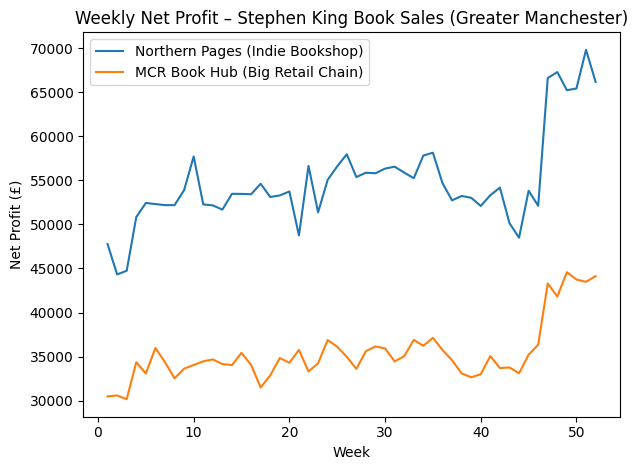

In [2]:
import matplotlib.pyplot as plt

plt.figure()
for b in weekly["business_name"].unique():
    df = weekly[weekly["business_name"] == b]
    plt.plot(df["week"], df["net_profit"], label=b)

plt.xlabel("Week")
plt.ylabel("Net Profit (£)")
plt.title("Weekly Net Profit – Stephen King Book Sales (Greater Manchester)")
plt.legend()
plt.tight_layout()
plt.show()


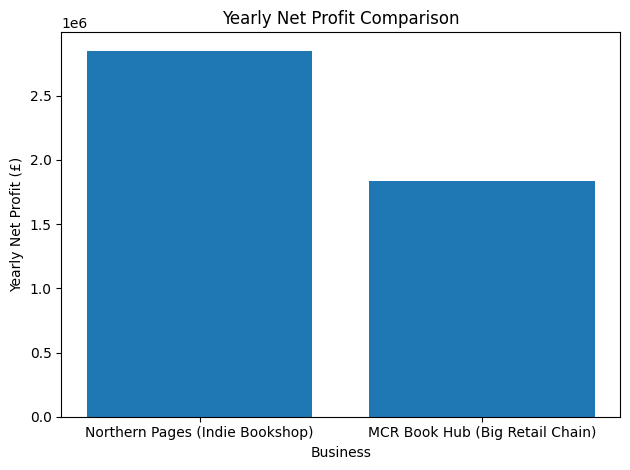

In [3]:
plt.figure()
plt.bar(yearly["business_name"], yearly["net_profit"])
plt.xlabel("Business")
plt.ylabel("Yearly Net Profit (£)")
plt.title("Yearly Net Profit Comparison")
plt.tight_layout()
plt.show()


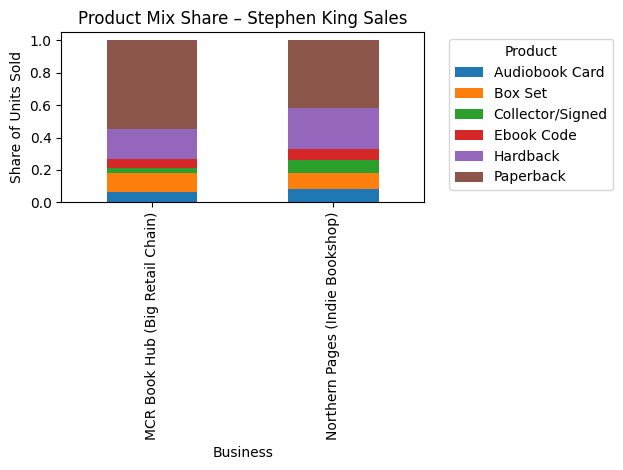

In [4]:
pivot_menu = menu_mix_actual.pivot(
    index="business_name",
    columns="product",
    values="unit_share"
).fillna(0)

pivot_menu.plot(kind="bar", stacked=True)
plt.xlabel("Business")
plt.ylabel("Share of Units Sold")
plt.title("Product Mix Share – Stephen King Sales")
plt.legend(title="Product", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


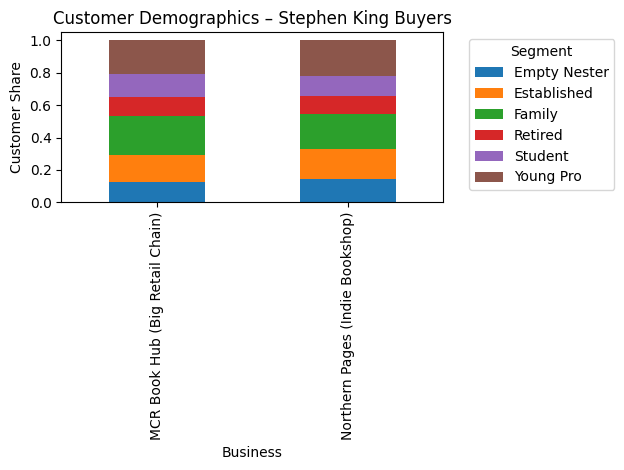

In [5]:
pivot_demo = demo.pivot(
    index="business_name",
    columns="segment",
    values="segment_share_units"
).fillna(0)

pivot_demo.plot(kind="bar", stacked=True)
plt.xlabel("Business")
plt.ylabel("Customer Share")
plt.title("Customer Demographics – Stephen King Buyers")
plt.legend(title="Segment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5205/3773084345.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=weekly["business_name"].unique())


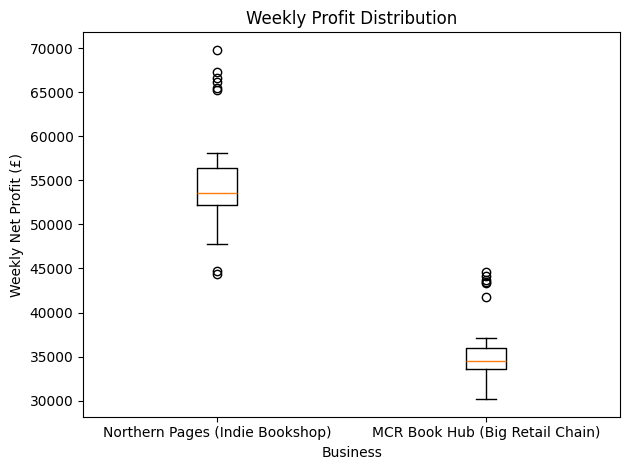

In [6]:
plt.figure()
data = [
    weekly[weekly["business_name"] == b]["net_profit"]
    for b in weekly["business_name"].unique()
]

plt.boxplot(data, labels=weekly["business_name"].unique())
plt.xlabel("Business")
plt.ylabel("Weekly Net Profit (£)")
plt.title("Weekly Profit Distribution")
plt.tight_layout()
plt.show()


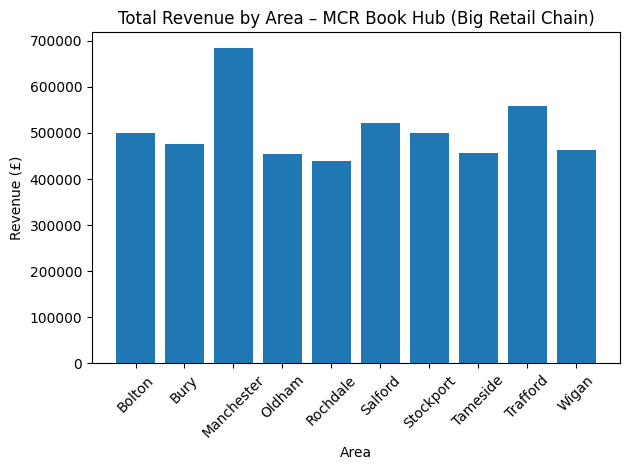

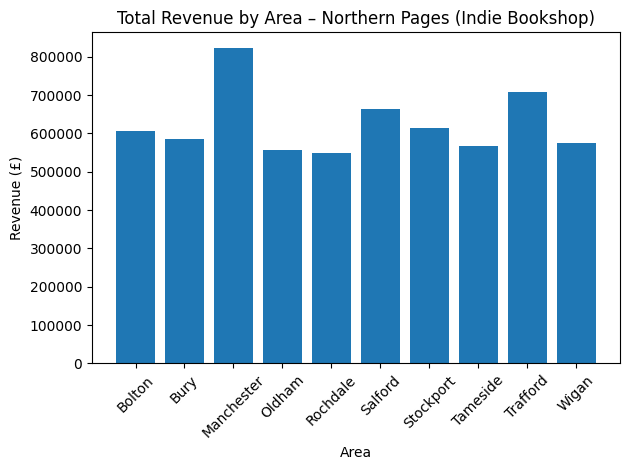

In [7]:
area_revenue = (
    sales_df
    .groupby(["business_name", "area"], as_index=False)
    .agg(revenue=("revenue", "sum"))
)

for b in area_revenue["business_name"].unique():
    df = area_revenue[area_revenue["business_name"] == b]
    plt.figure()
    plt.bar(df["area"], df["revenue"])
    plt.xticks(rotation=45)
    plt.xlabel("Area")
    plt.ylabel("Revenue (£)")
    plt.title(f"Total Revenue by Area – {b}")
    plt.tight_layout()
    plt.show()
